In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [6]:
data = pd.read_csv("../../data/vehicle/car_details_v3.csv")
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [8]:
features = ['year','km_driven', 'engine', 'max_power',]
y = data['selling_price']
x = data[features]
for col in ['engine', 'max_power']:
    x[col] = pd.to_numeric(
        x[col].str.split().str[0],
        errors='coerce'
    )
x

,year,km_driven,engine,max_power
0,2014,145500,1248.0,74.00
1,2014,120000,1498.0,103.52
2,2006,140000,1497.0,78.00
3,2010,127000,1396.0,90.00
4,2007,120000,1298.0,88.20
...,...,...,...,...
8123,2013,110000,1197.0,82.85
8124,2007,119000,1493.0,110.00
8125,2009,120000,1248.0,73.90
8126,2013,25000,1396.0,70.00


In [17]:
x_train,x_temp,y_train,y_temp = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=42
)

x_val,x_test,y_val,y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

for i in ['engine', 'max_power']:
    engine_median = x_train[i].median()
    x_train[i] = x_train[i].fillna(engine_median)
    x_val[i] = x_val[i].fillna(engine_median)
    x_test[i] = x_test[i].fillna(engine_median)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_val = scaler.transform(x_val)

x_test = scaler.transform(x_test)


In [24]:
# linear model
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)
linear_model.score(x_val,y_val)

0.6419393582167916

In [25]:
# random forest
random_forest_model = RandomForestRegressor()
random_forest_model.fit(x_train,y_train)
random_forest_model.score(x_val,y_val)

0.9387542913746687

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_l_pred  =linear_model.predict(x_test)
y_r_pred  =random_forest_model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_l_pred))
r2 = r2_score(y_test, y_l_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 479091.26162227575
R²: 0.644036721652301


In [27]:
rmse = np.sqrt(mean_squared_error(y_test, y_r_pred))
r2 = r2_score(y_test, y_r_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 152977.9174581636
R²: 0.9637067226570616


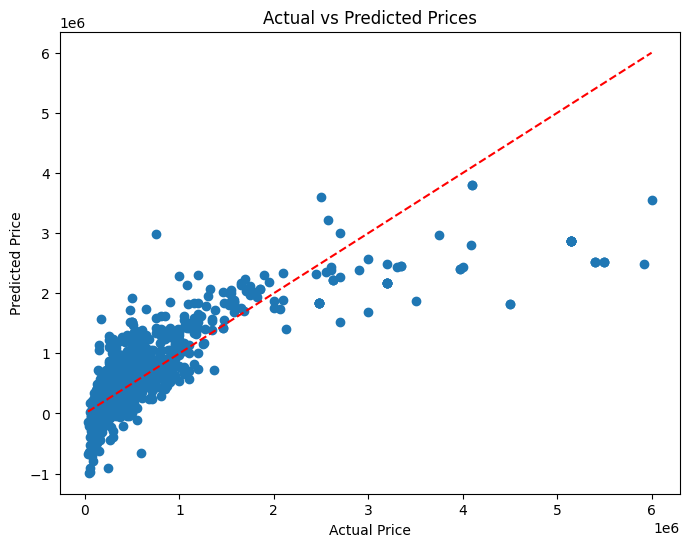

In [30]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_l_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

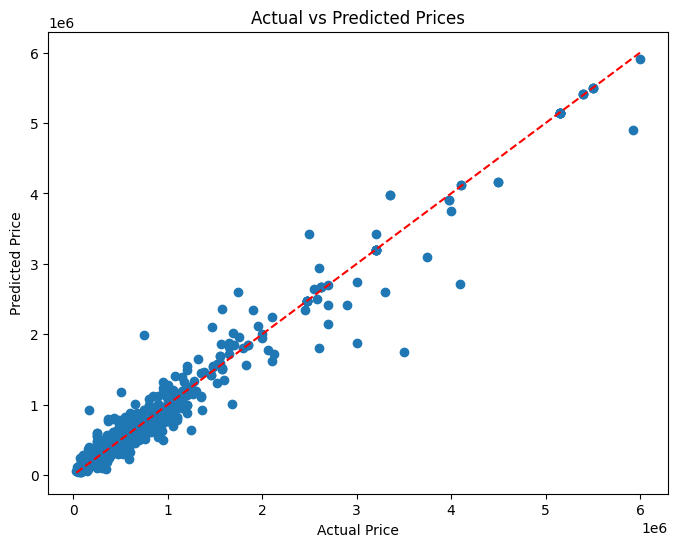

In [35]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_r_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()